In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

pd.set_option('display.max_colwidth', 200)

In [34]:
BASE_PATH = '/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/ASRS'

csv_files = [f for f in os.listdir(BASE_PATH) if f.endswith('.csv')]
print(f"Found {len(csv_files)} file(s): {csv_files}")

# Load each file separately first to check they have the same structure before merging
dfs_raw = {}
for file in csv_files:
    df = pd.read_csv(f'{BASE_PATH}/{file}', skiprows=[1])
    dfs_raw[file] = df
    print(f"\n{file}: {df.shape[0]} rows, {df.shape[1]} columns")

# Confirm both files have identical column structure before concatenating
cols_match = all(set(df.columns) == set(list(dfs_raw.values())[0].columns) for df in dfs_raw.values())
print(f"\nColumn structures match across files: {cols_match}")

Found 2 file(s): ['ASRS_DBOnline_part1.csv', 'ASRS_DBOnline_part2.csv']

ASRS_DBOnline_part1.csv: 4956 rows, 126 columns

ASRS_DBOnline_part2.csv: 4993 rows, 126 columns

Column structures match across files: True


In [35]:
# Combine both files into one dataset

raw_df = pd.concat(list(dfs_raw.values()), ignore_index=True)
print(f"Combined dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")

raw_df.head(3)

Combined dataset: 9949 rows, 126 columns


,,Time,Time.1,Place,Place.1,Place.2,Place.3,Place.4,Place.5,Place.6,...,Events.4,Events.5,Assessments,Assessments.1,Report 1,Report 1.1,Report 2,Report 2.1,Report 1.2,Unnamed: 125
0,118937,198908,0601-1200,BNA,TN,20.0,5.0,NaN,2000.0,NaN,...,NaN,Aircraft Aircraft Damaged; General Declared Emergency,NaN,Aircraft,CARGO HANDLERS FINISHED LOADING ACFT AND SECURED AFT CARGO DOOR CLOSED. AFTER CARGO HANDLERS EXITED THRU FORWARD CREW ENTRY DOOR; FLT CREW NOTICED THAT THE AFT CARGO DOOR LOCKED LIGHT WAS STILL IL...,NaN,NaN,NaN,CARGO DOOR WARNING LIGHT CAME ON SHORTLY AFTER TKOF. FLT CREW RETURNED AND LANDED.,NaN
1,119181,198908,1801-2400,YKM,WA,310.0,26.0,NaN,6500.0,NaN,...,NaN,General None Reported / Taken,NaN,Human Factors,ENRTE FROM SEATTLE; WA TO YAKIMA; WA; WE WERE AT 13;000'. MY F/O WAS FLYING; AND I ELECTED TO XFEED BOTH ENGINES FROM THE RIGHT FUEL TANK TO CORRECT A 100 LB FUEL IMBALANCE. (WE LEFT SEATTLE WITH ...,NaN,NaN,NaN,THE FLT CREW OF A COMMUTER ACFT BEGINS FUEL CROSSFEED AT THE BEGINNING OF DESCENT TO CORRECT A MINOR FUEL IMBALANCE. TANK EXHAUSTION AND ENGINE FLAMEOUT OCCUR ABOUT 5 MINUTES LATER AT APPROX 20 MI...,NaN
2,119283,198908,1201-1800,LOA,TX,40.0,10.0,NaN,8000.0,NaN,...,NaN,General Declared Emergency; General None Reported / Taken,NaN,Airport,30 MIN AFTER DEP; DURING CRUISE FLT; AN OIL LEAK WAS NOTICED ACROSS THE WINDSHIELD WHICH RAPIDLY INCREASED AND COMPLETELY OBSCURED FORWARD VISION. PREPARATIONS WERE MADE FOR POWER-OFF LNDG. ROUTE ...,NaN,NaN,NaN,GA SMA LOSS OF ENGINE OIL AT CRUISE ALT. DIVERSION TO ALTERNATE.,NaN


In [36]:
raw_df.shape

(9949, 126)

In [37]:
# Check for and remove duplicate reports

acn_candidates = [c for c in raw_df.columns if 'accession' in c.lower() or 'acn' in c.lower()]
print(f"ACN/Accession number column(s) found: {acn_candidates}")

if acn_candidates:
    acn_col = acn_candidates[0]
    duplicate_count = raw_df.duplicated(subset=[acn_col]).sum()
    print(f"Duplicate reports (same ACN appearing in both files): {duplicate_count}")

    raw_df = raw_df.drop_duplicates(subset=[acn_col], keep='first')
    print(f"Rows after removing duplicates: {raw_df.shape[0]}")
else:
    print("No ACN column found — skipping dedup, will need manual column check")

ACN/Accession number column(s) found: []
No ACN column found — skipping dedup, will need manual column check


In [38]:
print("="*60)
print("ALL COLUMNS")
print("="*60)
for col in raw_df.columns:
    print(col)


ALL COLUMNS
 
Time
Time.1
Place
Place.1
Place.2
Place.3
Place.4
Place.5
Place.6
Environment
Environment.1
Environment.2
Environment.3
Environment.4
Environment.5
Aircraft 1
Aircraft 1.1
Aircraft 1.2
Aircraft 1.3
Aircraft 1.4
Aircraft 1.5
Aircraft 1.6
Aircraft 1.7
Aircraft 1.8
Aircraft 1.9
Aircraft 1.10
Aircraft 1.11
Aircraft 1.12
Aircraft 1.13
Aircraft 1.14
Aircraft 1.15
Aircraft 1.16
Aircraft 1.17
Aircraft 1.18
Aircraft 1.19
Aircraft 1.20
Aircraft 1.21
Aircraft 1.22
Aircraft 1.23
Aircraft 1.24
Aircraft 1.25
Aircraft 1.26
Aircraft 1.27
Aircraft 1.28
Aircraft 1.29
Aircraft 1.30
Aircraft 1.31
Aircraft 1.32
Aircraft 1.33
Aircraft 1.34
Component
Component.1
Component.2
Component.3
Aircraft 2
Aircraft 2.1
Aircraft 2.2
Aircraft 2.3
Aircraft 2.4
Aircraft 2.5
Aircraft 2.6
Aircraft 2.7
Aircraft 2.8
Aircraft 2.9
Aircraft 2.10
Aircraft 2.11
Aircraft 2.12
Aircraft 2.13
Aircraft 2.14
Aircraft 2.15
Aircraft 2.16
Aircraft 2.17
Aircraft 2.18
Aircraft 2.19
Aircraft 2.20
Aircraft 2.21
Aircraft 2.22
Airc

In [39]:
print("\n" + "="*60)
print("NULL VALUE COUNTS (sorted)")
print("="*60)
print(raw_df.isnull().sum().sort_values(ascending=False))


NULL VALUE COUNTS (sorted)
Place.6          9949
Aircraft 1.24    9949
Aircraft 1.32    9949
Aircraft 2.3     9949
Aircraft 1.22    9949
                 ... 
                    0
Time                0
Events              0
Report 1            0
Report 1.2          0
Length: 126, dtype: int64


In [40]:
report_cols = [c for c in raw_df.columns if c.startswith('Report')]
print(f"Candidate 'Report' columns: {report_cols}")

print("\n" + "="*60)
print("AVERAGE TEXT LENGTH PER 'Report' COLUMN")
print("="*60)

col_stats = []
for col in report_cols:
    text_lengths = raw_df[col].dropna().astype(str).apply(lambda x: len(x.split()))
    avg_len = text_lengths.mean() if len(text_lengths) > 0 else 0
    non_null = raw_df[col].notna().sum()
    col_stats.append({'column': col, 'avg_word_count': avg_len, 'non_null_count': non_null})

stats_df = pd.DataFrame(col_stats).sort_values('avg_word_count', ascending=False)
print(stats_df)

Candidate 'Report' columns: ['Report 1', 'Report 1.1', 'Report 2', 'Report 2.1', 'Report 1.2']

AVERAGE TEXT LENGTH PER 'Report' COLUMN
       column  avg_word_count  non_null_count
0    Report 1      344.052769            9949
2    Report 2      221.228792            2723
1  Report 1.1      129.864224             464
3  Report 2.1      109.568182              44
4  Report 1.2       29.475023            9949


In [41]:
for col in report_cols:
    sample = raw_df[col].dropna().iloc[0] if raw_df[col].notna().sum() > 0 else None
    print(f"\n{'='*60}")
    print(f"COLUMN: {col}")
    print(f"{'='*60}")
    print(str(sample)[:400] if sample else "EMPTY")


COLUMN: Report 1
CARGO HANDLERS FINISHED LOADING ACFT AND SECURED AFT CARGO DOOR CLOSED. AFTER CARGO HANDLERS EXITED THRU FORWARD CREW ENTRY DOOR; FLT CREW NOTICED THAT THE AFT CARGO DOOR LOCKED LIGHT WAS STILL ILLUMINATED. AS CAPT; I WALKED TO THE BACK; AFT CARGO DOOR; AND CHECKED THAT ALL BOTTOM LATCHES WERE DOWN/LOCKED AND THAT BUNGEE CORDS (STRAPS) WERE SECURED. THE SIDE LATCH (CARGO DOOR LIGHT SYSTEM CONNECTE

COLUMN: Report 1.1
Reporter stated the hot-section area repair work that was actually accomplished on both engines; was equivalent to an 1800 hour hot-section inspection. With all the work; inspections and components that were replaced; the engine manufacturer would not state on the FAA 8130-3 serviceable tags; the JT15D-5 engines had satisfied the 1800 hour inspection requirements.  The misunderstanding came from h

COLUMN: Report 2
The station provided us no help whatsoever. I suggested that we clear through the Customs then go on our own to find a small office; which we 

In [42]:
# Build narrative, callback, and synopsis fields

raw_df['narrative_combined'] = (
    raw_df['Report 1'].fillna('') + ' ' + raw_df['Report 2'].fillna('')
).str.strip()

raw_df['callback_combined'] = (
    raw_df['Report 1.1'].fillna('') + ' ' + raw_df['Report 2.1'].fillna('')
).str.strip()

raw_df['synopsis'] = raw_df['Report 1.2'].fillna('').str.strip()

raw_df['narrative_word_count'] = raw_df['narrative_combined'].apply(lambda x: len(x.split()))

print(f"Reports with usable narrative: {(raw_df['narrative_word_count'] > 5).sum()} / {len(raw_df)}")
print(f"Reports with a callback present: {(raw_df['callback_combined'].str.len() > 5).sum()}")
print(f"Reports with synopsis: {(raw_df['synopsis'].str.len() > 5).sum()}")

raw_df[['narrative_combined', 'synopsis', 'narrative_word_count']].head(3)

Reports with usable narrative: 9949 / 9949
Reports with a callback present: 497
Reports with synopsis: 9949


,narrative_combined,synopsis,narrative_word_count
0,CARGO HANDLERS FINISHED LOADING ACFT AND SECURED AFT CARGO DOOR CLOSED. AFTER CARGO HANDLERS EXITED THRU FORWARD CREW ENTRY DOOR; FLT CREW NOTICED THAT THE AFT CARGO DOOR LOCKED LIGHT WAS STILL IL...,CARGO DOOR WARNING LIGHT CAME ON SHORTLY AFTER TKOF. FLT CREW RETURNED AND LANDED.,238
1,ENRTE FROM SEATTLE; WA TO YAKIMA; WA; WE WERE AT 13;000'. MY F/O WAS FLYING; AND I ELECTED TO XFEED BOTH ENGINES FROM THE RIGHT FUEL TANK TO CORRECT A 100 LB FUEL IMBALANCE. (WE LEFT SEATTLE WITH ...,THE FLT CREW OF A COMMUTER ACFT BEGINS FUEL CROSSFEED AT THE BEGINNING OF DESCENT TO CORRECT A MINOR FUEL IMBALANCE. TANK EXHAUSTION AND ENGINE FLAMEOUT OCCUR ABOUT 5 MINUTES LATER AT APPROX 20 MI...,588
2,30 MIN AFTER DEP; DURING CRUISE FLT; AN OIL LEAK WAS NOTICED ACROSS THE WINDSHIELD WHICH RAPIDLY INCREASED AND COMPLETELY OBSCURED FORWARD VISION. PREPARATIONS WERE MADE FOR POWER-OFF LNDG. ROUTE ...,GA SMA LOSS OF ENGINE OIL AT CRUISE ALT. DIVERSION TO ALTERNATE.,138


In [43]:
raw_df.shape

(9949, 130)

In [44]:
raw_df.columns

Index([' ', 'Time', 'Time.1', 'Place', 'Place.1', 'Place.2', 'Place.3',
       'Place.4', 'Place.5', 'Place.6',
       ...
       'Report 1', 'Report 1.1', 'Report 2', 'Report 2.1', 'Report 1.2',
       'Unnamed: 125', 'narrative_combined', 'callback_combined', 'synopsis',
       'narrative_word_count'],
      dtype='object', length=130)

NARRATIVE LENGTH STATISTICS (words)
count    9949.000000
mean      404.602171
std       325.515366
min         7.000000
25%       185.000000
50%       314.000000
75%       523.000000
max      3690.000000
Name: narrative_word_count, dtype: float64


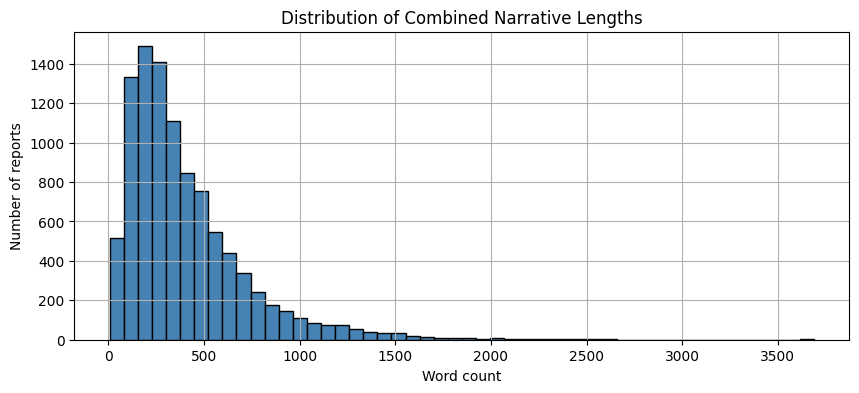

In [45]:
print("="*60)
print("NARRATIVE LENGTH STATISTICS (words)")
print("="*60)
print(raw_df['narrative_word_count'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
raw_df['narrative_word_count'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Combined Narrative Lengths')
plt.xlabel('Word count')
plt.ylabel('Number of reports')
plt.show()

In [46]:
# Remove unusable rows

clean_df = raw_df[raw_df['narrative_word_count'] > 5].copy()
print(f"Usable reports: {len(clean_df)} / {len(raw_df)} ({len(clean_df)/len(raw_df)*100:.2f}% retained)")

Usable reports: 9949 / 9949 (100.00% retained)


In [47]:
# Positional inspection of metadata field groups

print("="*60)
print("Aircraft 1 FIELDS (row 0)")
print("="*60)
aircraft_cols = [c for c in clean_df.columns if c.startswith('Aircraft 1') and not c.startswith('Aircraft 1.') == False]
aircraft_cols = [c for c in clean_df.columns if c.startswith('Aircraft 1')]
for col in aircraft_cols:
    print(f"{col}: {clean_df[col].iloc[0]}")

print("\n" + "="*60)
print("Component FIELDS (row 0)")
print("="*60)
component_cols = [c for c in clean_df.columns if c.startswith('Component')]
for col in component_cols:
    print(f"{col}: {clean_df[col].iloc[0]}")

print("\n" + "="*60)
print("Events FIELDS (row 0)")
print("="*60)
events_cols = [c for c in clean_df.columns if c.startswith('Events')]
for col in events_cols:
    print(f"{col}: {clean_df[col].iloc[0]}")

print("\n" + "="*60)
print("Person 1 FIELDS (row 0)")
print("="*60)
person_cols = [c for c in clean_df.columns if c.startswith('Person 1')]
for col in person_cols:
    print(f"{col}: {clean_df[col].iloc[0]}")

print("\n" + "="*60)
print("Time / Place FIELDS (row 0)")
print("="*60)
for col in ['Time', 'Time.1', 'Place', 'Place.1', 'Place.2', 'Place.3', 'Place.4', 'Place.5', 'Place.6']:
    print(f"{col}: {clean_df[col].iloc[0]}")

Aircraft 1 FIELDS (row 0)
Aircraft 1: TRACON BNA; Tower BNA
Aircraft 1.1: Air Taxi
Aircraft 1.2: Medium Transport; Low Wing; 2 Turboprop Eng
Aircraft 1.3: nan
Aircraft 1.4: 2
Aircraft 1.5: nan
Aircraft 1.6: IFR
Aircraft 1.7: Cargo / Freight / Delivery
Aircraft 1.8: nan
Aircraft 1.9: Landing; Takeoff / Launch; Landing
Aircraft 1.10: Vectors
Aircraft 1.11: Class D BNA
Aircraft 1.12: nan
Aircraft 1.13: nan
Aircraft 1.14: nan
Aircraft 1.15: nan
Aircraft 1.16: nan
Aircraft 1.17: nan
Aircraft 1.18: nan
Aircraft 1.19: nan
Aircraft 1.20: nan
Aircraft 1.21: nan
Aircraft 1.22: nan
Aircraft 1.23: nan
Aircraft 1.24: nan
Aircraft 1.25: nan
Aircraft 1.26: nan
Aircraft 1.27: nan
Aircraft 1.28: nan
Aircraft 1.29: nan
Aircraft 1.30: nan
Aircraft 1.31: nan
Aircraft 1.32: nan
Aircraft 1.33: nan
Aircraft 1.34: nan

Component FIELDS (row 0)
Component: nan
Component.1: nan
Component.2: nan
Component.3: nan

Events FIELDS (row 0)
Events: Aircraft Equipment Problem Critical
Events.1: nan
Events.2: nan
Events.

In [48]:
#  Check date distribution

clean_df['report_date'] = clean_df['Time'].astype(str).str[:6]
clean_df['report_year'] = clean_df['report_date'].str[:4]

print("="*60)
print("REPORT YEAR DISTRIBUTION")
print("="*60)
print(clean_df['report_year'].value_counts().sort_index())

REPORT YEAR DISTRIBUTION
report_year
1989     48
1990     25
1991      5
1992      5
1993      7
1994      8
1995     19
1996      9
1997     16
1998     22
1999     17
2000     18
2001     40
2002     12
2003     20
2004     22
2005     19
2006     17
2007     63
2008    113
2009    587
2010    645
2011    603
2012    621
2013    567
2014    418
2015    509
2016    501
2017    169
2018    489
2019    597
2020    393
2021    495
2022    797
2023    547
2024    632
2025    732
2026    142
Name: count, dtype: int64


In [49]:
for i in range(5):
    print(f"Row {i}: model={clean_df['Aircraft 1.2'].iloc[i]!r}, "
          f"phase={clean_df['Aircraft 1.9'].iloc[i]!r}, "
          f"acn={clean_df['Person 1.10'].iloc[i]!r}")

Row 0: model='Medium Transport; Low Wing; 2 Turboprop Eng', phase='Landing; Takeoff / Launch; Landing', acn=np.float64(118937.0)
Row 1: model='Light Transport; Low Wing; 2 Turboprop Eng', phase='Descent; Descent', acn=np.float64(119181.0)
Row 2: model='Small Aircraft; Low Wing; 1 Eng; Retractable Gear', phase='Cruise; Cruise', acn=np.float64(119283.0)
Row 3: model='Small Transport; Low Wing; 2 Turboprop Eng', phase='Initial Climb; Landing; Landing', acn=np.float64(119633.0)
Row 4: model='Small Aircraft; High Wing; 1 Eng; Fixed Gear', phase='Takeoff / Launch; Landing; Landing; Other Pattern', acn=np.float64(119723.0)


In [50]:
YEAR_CUTOFF = 2009

clean_df = clean_df[clean_df['report_year'].astype(int) >= YEAR_CUTOFF].copy()
print(f"Reports after filtering to {YEAR_CUTOFF}+: {len(clean_df)}")
print(clean_df['report_year'].value_counts().sort_index())

Reports after filtering to 2009+: 9444
report_year
2009    587
2010    645
2011    603
2012    621
2013    567
2014    418
2015    509
2016    501
2017    169
2018    489
2019    597
2020    393
2021    495
2022    797
2023    547
2024    632
2025    732
2026    142
Name: count, dtype: int64


In [51]:
clean_df.shape

(9444, 132)

In [52]:
clean_df['acn'] = clean_df['Person 1.10']
clean_df['acn'] = clean_df['acn'].astype('Int64').astype(str)
clean_df['aircraft_model'] = clean_df['Aircraft 1.2']
clean_df['flight_phase'] = clean_df['Aircraft 1.9']
clean_df['mission'] = clean_df['Aircraft 1.7']
clean_df['aircraft_operator'] = clean_df['Aircraft 1.1']
clean_df['airport'] = clean_df['Place']
clean_df['state'] = clean_df['Place.1']
clean_df['anomaly_events'] = clean_df['Events']

print(f"Reports with valid ACN: {clean_df['acn'].notna().sum()} / {len(clean_df)}")
print(f"\nTop aircraft models:")
print(clean_df['aircraft_model'].value_counts().head(10))
print(f"\nTop flight phases:")
print(clean_df['flight_phase'].value_counts().head(10))

Reports with valid ACN: 9444 / 9444

Top aircraft models:
aircraft_model
A320                                    472
B737-800                                421
Skyhawk 172/Cutlass 172                 413
A319                                    361
B737 Undifferentiated or Other Model    346
B737-700                                346
B757-200                                319
A321                                    314
Commercial Fixed Wing                   267
B767-300 and 300 ER                     260
Name: count, dtype: int64

Top flight phases:
flight_phase
Cruise              1987
Parked              1588
Climb               1368
Takeoff / Launch    1334
Initial Climb        544
Taxi                 543
Descent              505
Landing              367
Initial Approach     343
Final Approach       189
Name: count, dtype: int64


In [53]:
#  Deduplicate using ACN
duplicate_count = clean_df.duplicated(subset=['acn']).sum()
print(f"Duplicate ACNs found: {duplicate_count}")

clean_df = clean_df.drop_duplicates(subset=['acn'], keep='first')
print(f"Rows after deduplication: {len(clean_df)}")

Duplicate ACNs found: 1
Rows after deduplication: 9443


In [54]:
import re

sample_narratives = clean_df['narrative_combined'].sample(30, random_state=42)
common_abbrevs = ['EGT', 'ATC', 'ALT', 'N1', 'N2', 'ECAM', 'EICAS', 'MEL', 'APU', 'ARFF', 'QRH', 'QRC']

abbrev_counts = {a: 0 for a in common_abbrevs}
for text in sample_narratives:
    text_upper = str(text).upper()
    for abbr in common_abbrevs:
        abbrev_counts[abbr] += len(re.findall(r'\b' + abbr + r'\b', text_upper))

print("="*60)
print("ABBREVIATION FREQUENCY IN 30 SAMPLE NARRATIVES")
print("="*60)
for abbr, count in sorted(abbrev_counts.items(), key=lambda x: -x[1]):
    print(f"{abbr}: {count}")

ABBREVIATION FREQUENCY IN 30 SAMPLE NARRATIVES
APU: 20
ATC: 17
QRH: 14
N1: 13
EGT: 6
ECAM: 6
MEL: 6
N2: 3
EICAS: 3
QRC: 1
ALT: 0
ARFF: 0


In [55]:
output_dir = f'{BASE_PATH}/processed'
os.makedirs(output_dir, exist_ok=True)
output_path = f'{output_dir}/asrs_cleaned.csv'

final_cols = ['acn', 'narrative_combined', 'synopsis', 'callback_combined',
              'narrative_word_count', 'aircraft_model', 'flight_phase',
              'mission', 'aircraft_operator', 'airport', 'state',
              'anomaly_events', 'report_year', 'report_date']

clean_df[final_cols].to_csv(output_path, index=False)
print(f"Saved {len(clean_df)} cleaned reports to {output_path}")

print("\n" + "="*60)
print("SUMMARY FOR NEXT NOTEBOOK")
print("="*60)
print(f"Median narrative length: {clean_df['narrative_word_count'].median():.0f} words")
print(f"Year range: {clean_df['report_year'].min()} - {clean_df['report_year'].max()}")
print(f"Top aircraft models: {clean_df['aircraft_model'].value_counts().head(5).to_dict()}")

Saved 9443 cleaned reports to /content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/ASRS/processed/asrs_cleaned.csv

SUMMARY FOR NEXT NOTEBOOK
Median narrative length: 316 words
Year range: 2009 - 2026
Top aircraft models: {'A320': 472, 'B737-800': 421, 'Skyhawk 172/Cutlass 172': 413, 'A319': 361, 'B737 Undifferentiated or Other Model': 346}
